## Figure S6A

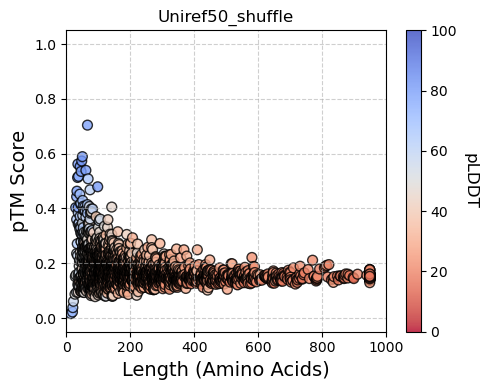

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import io

df = pd.read_csv("../RELIC_data/figure5_S6/uniref50_shuffle_summary.csv")

fig, ax = plt.subplots(figsize=(5, 4))

vmin = 0
vmax = 100
scatter = ax.scatter(
    df['Length'],
    df['pTM'],
    c=df['pLDDT'],
    cmap='coolwarm_r',
    vmin=vmin,
    vmax=vmax,
    s=50,
    edgecolors='k',
    alpha=0.8)
cbar = fig.colorbar(scatter, ax=ax)
cbar.set_label('pLDDT', rotation=270, labelpad=15, fontsize=12)
ax.set_title('Uniref50_shuffle')
ax.set_xlabel('Length (Amino Acids)', fontsize=14)
ax.set_ylabel('pTM Score', fontsize=14)
ax.set_xlim(0,1000)
ax.set_ylim(-0.05,1.05)
ax.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

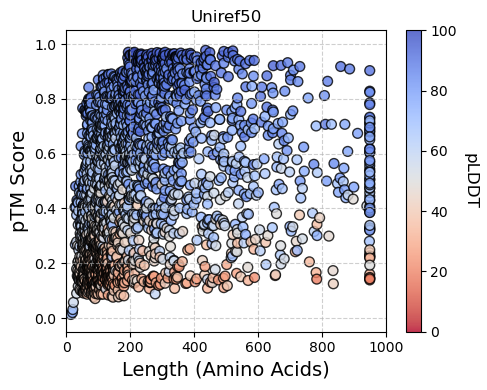

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import io

df = pd.read_csv("../RELIC_data/figure5_S6/uniref50_sampled_summary.csv")

fig, ax = plt.subplots(figsize=(5, 4))

vmin = 0
vmax = 100
scatter = ax.scatter(
    df['Length'],
    df['pTM'],
    c=df['pLDDT'],
    cmap='coolwarm_r',
    vmin=vmin,
    vmax=vmax,
    s=50,
    edgecolors='k',
    alpha=0.8)
cbar = fig.colorbar(scatter, ax=ax)
cbar.set_label('pLDDT', rotation=270, labelpad=15, fontsize=12)
ax.set_title('Uniref50')
ax.set_xlabel('Length (Amino Acids)', fontsize=14)
ax.set_ylabel('pTM Score', fontsize=14)
ax.set_xlim(0,1000)
ax.set_ylim(-0.05,1.05)
ax.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

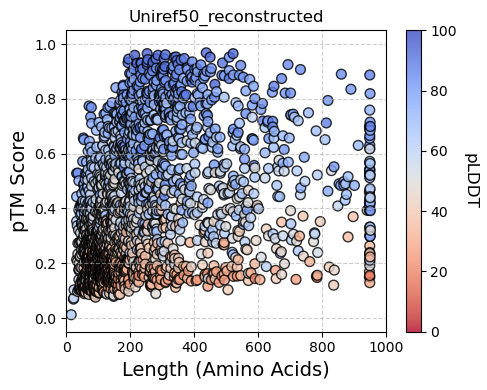

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import io

df = pd.read_csv("../RELIC_data/figure5_S6/uniref50_reconstructed_summary.csv")

fig, ax = plt.subplots(figsize=(5, 4))

vmin = 0
vmax = 100
scatter = ax.scatter(
    df['Length'],
    df['pTM'],
    c=df['pLDDT'],
    cmap='coolwarm_r',
    vmin=vmin,
    vmax=vmax,
    s=50,
    edgecolors='k',
    alpha=0.8)
cbar = fig.colorbar(scatter, ax=ax)
cbar.set_label('pLDDT', rotation=270, labelpad=15, fontsize=12)
ax.set_title('Uniref50_reconstructed')
ax.set_xlabel('Length (Amino Acids)', fontsize=14)
ax.set_ylabel('pTM Score', fontsize=14)
ax.set_xlim(0,1000)
ax.set_ylim(-0.05,1.05)
ax.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

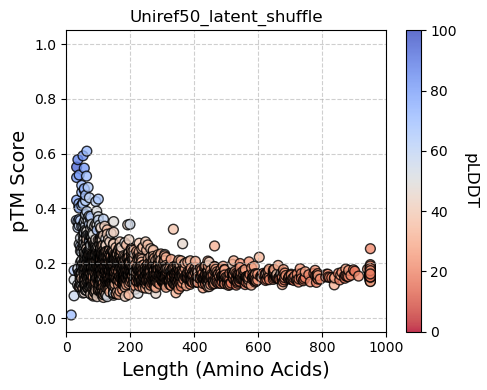

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import io

df = pd.read_csv("../RELIC_data/figure5_S6/uniref50_shuffle_latent_summary.csv")

fig, ax = plt.subplots(figsize=(5, 4))

vmin = 0
vmax = 100
scatter = ax.scatter(
    df['Length'],
    df['pTM'],
    c=df['pLDDT'],
    cmap='coolwarm_r',
    vmin=vmin,
    vmax=vmax,
    s=50,
    edgecolors='k',
    alpha=0.8)
cbar = fig.colorbar(scatter, ax=ax)
cbar.set_label('pLDDT', rotation=270, labelpad=15, fontsize=12)
ax.set_title('Uniref50_latent_shuffle')
ax.set_xlabel('Length (Amino Acids)', fontsize=14)
ax.set_ylabel('pTM Score', fontsize=14)
ax.set_xlim(0,1000)
ax.set_ylim(-0.05,1.05)
ax.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

## Figure S6 B

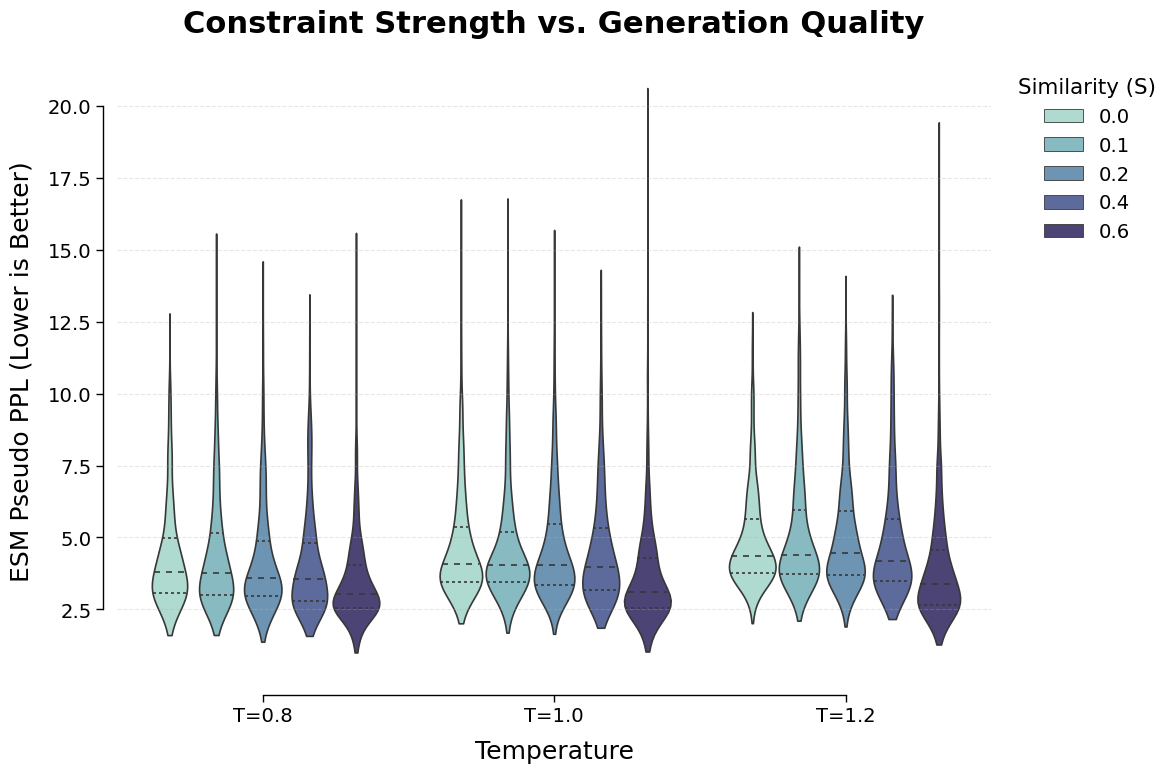

In [5]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os
import numpy as np

file_path = "../RELIC_data/figure5_S6/FULL_GRID_SEARCH_15k_ppl.csv"

if not os.path.exists(file_path):
    print(f"File not found: {file_path}")
    exit()

df_main = pd.read_csv(file_path)
df_main[['Temperature', 'Similarity']] = df_main['id'].str.extract(r'_T_([\d\.]+)_S_([\d\.]+)').astype(float)
ppl_col = [c for c in df_main.columns if 'ppl' in c.lower() or 'score' in c.lower()][0]

df_plot = pd.DataFrame({
    'ppl': df_main[ppl_col],
    'Label': df_main['Temperature'].apply(lambda x: f"T={x}"),
    'HueKey': df_main['Similarity']
})

unique_t = sorted(df_main['Temperature'].unique())
x_order = [f"T={t}" for t in unique_t]

unique_s = sorted(df_plot['HueKey'].unique())
colors = sns.cubehelix_palette(len(unique_s), start=.5, rot=-.5, dark=0.3, light=0.8)
exp_palette = {s: c for s, c in zip(unique_s, colors)}

plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'Helvetica', 'DejaVu Sans']
sns.set_context("paper", font_scale=1.6)
fig, ax = plt.subplots(figsize=(12, 8))

sns.violinplot(
    data=df_plot,
    x="Label",
    y="ppl",
    hue="HueKey",
    order=x_order,
    palette=exp_palette,
    ax=ax,
    linewidth=1.2,
    width=0.8,
    cut=0,
    inner="quartile",
    saturation=1
)

plt.ylabel("ESM Pseudo PPL (Lower is Better)", fontsize=18, labelpad=10)
plt.xlabel("Temperature", fontsize=18, labelpad=10)
plt.title("Constraint Strength vs. Generation Quality", fontsize=22, weight='bold', pad=20)

sns.despine(trim=True, offset=10)
ax.yaxis.grid(True, linestyle='--', alpha=0.3)

handles, labels = ax.get_legend_handles_labels()
ax.legend(
    handles, labels,
    title="Similarity (S)",
    loc='upper left',
    bbox_to_anchor=(1.01, 1),
    frameon=False
)

plt.tight_layout()
plt.show()

## Figure S6C

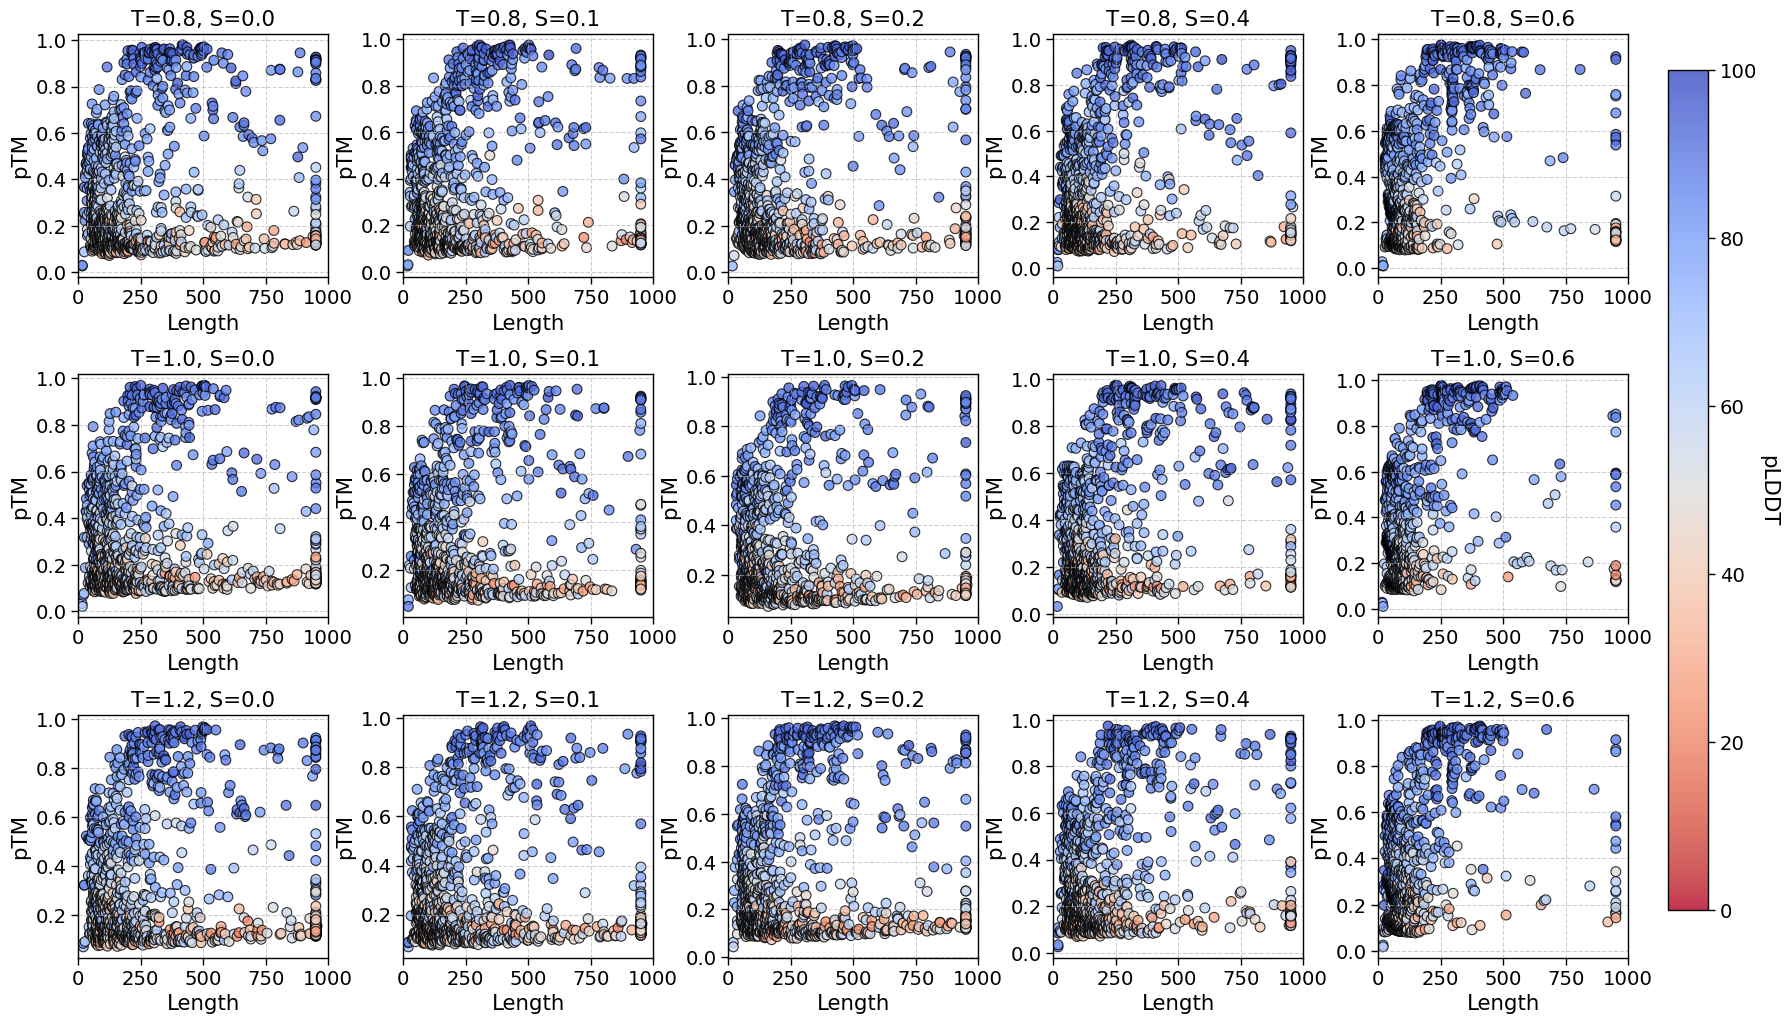

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import io
import math
import re

df = pd.read_csv('../RELIC_data/figure5_S6/grid_search_summary.csv')
def extract_t_s(name):
    match = re.search(r'T_(\d+\.?\d*)_S_(\d+\.?\d*)', name)
    if match:
        return float(match.group(1)), float(match.group(2))
    return None, None

df['T'], df['S'] = zip(*df['Sequence Name'].apply(extract_t_s))
groups = list(df.groupby(['T', 'S']))

num_plots = len(groups)
cols = 5 
rows = math.ceil(num_plots / cols)
fig, axes = plt.subplots(rows, cols, figsize=(20, 4 * rows))
axes = axes.flatten()
vmin = 0
vmax = 100

for i, ((t_val, s_val), group) in enumerate(groups):
    ax = axes[i]
    scatter = ax.scatter(group['Length'], group['pTM'], c=group['pLDDT'], cmap='coolwarm_r', vmin=vmin, vmax=vmax, s=50, edgecolors='k', alpha=0.8)
    ax.set_title(f'T={t_val}, S={s_val}')
    ax.set_xlim(0,1000)
    ax.set_xlabel('Length')
    ax.set_ylabel('pTM')
    ax.grid(True, linestyle='--', alpha=0.6)
cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
cbar = fig.colorbar(scatter, cax=cbar_ax)
cbar.set_label('pLDDT', rotation=270, labelpad=15)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.subplots_adjust(right=0.9, hspace=0.4, wspace=0.3)
plt.show()

## Figure S6D

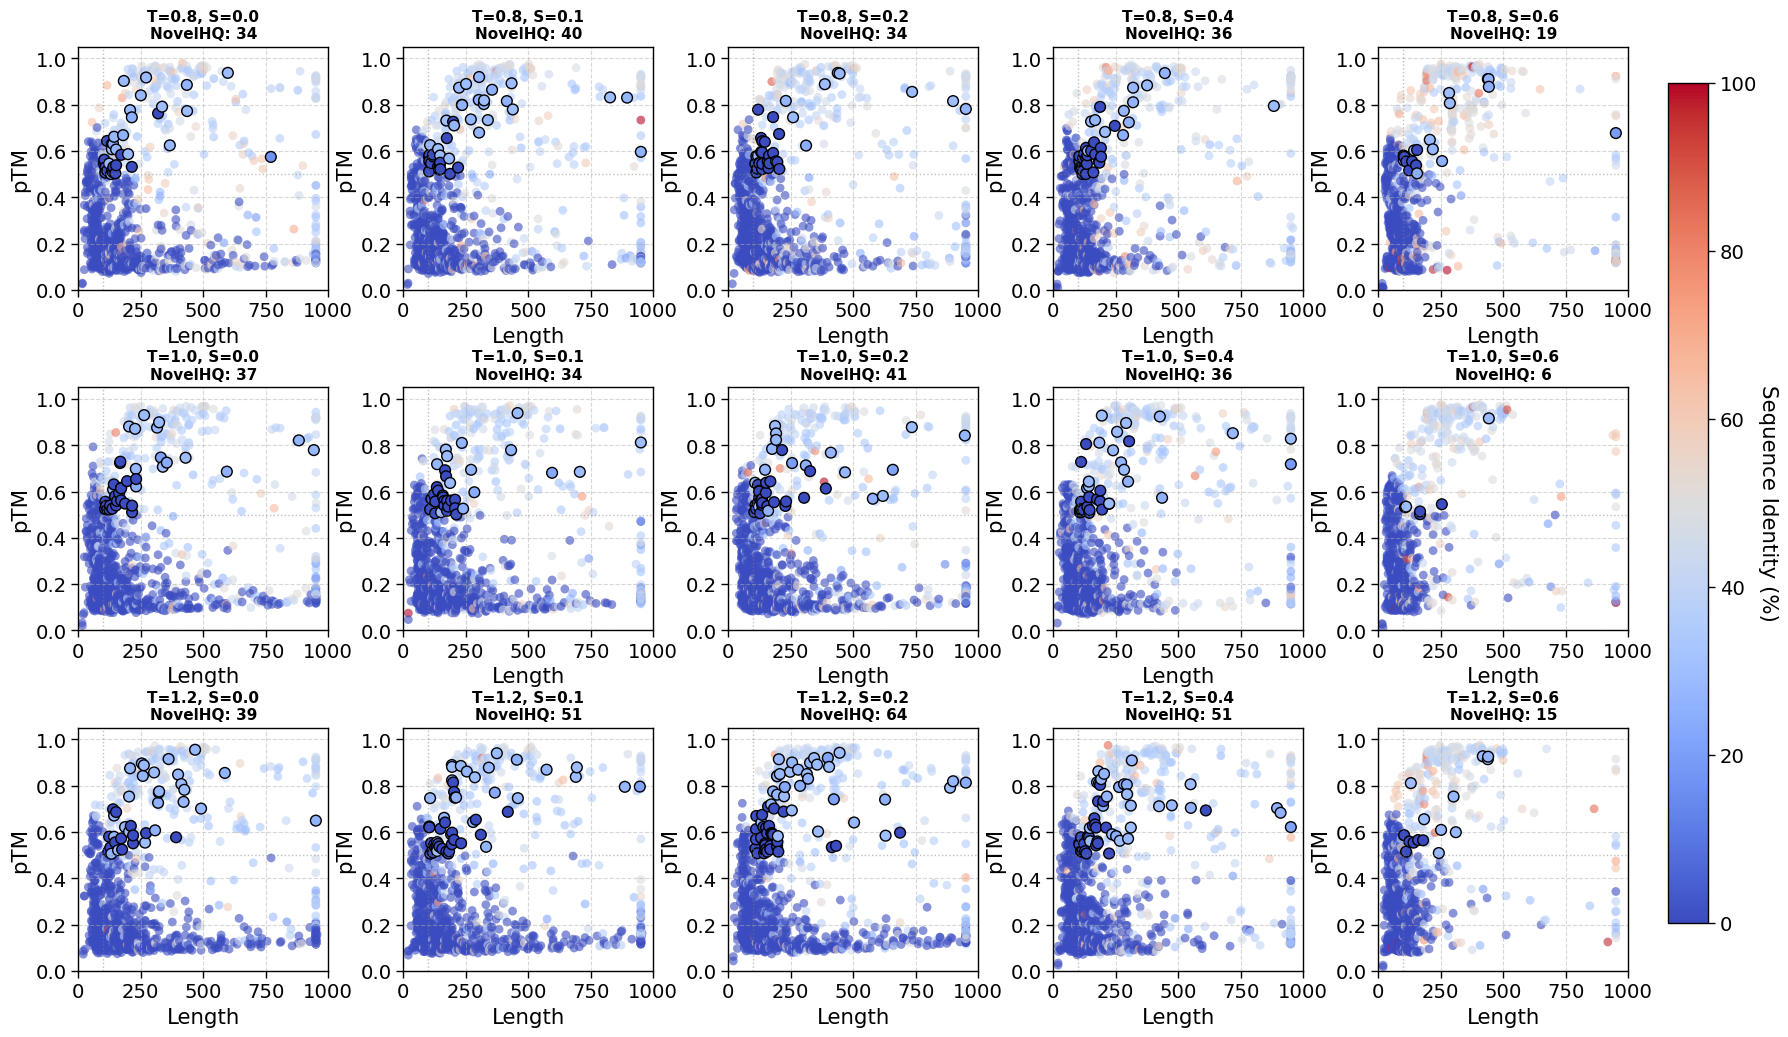

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import math
import re
import os
import matplotlib.cm as cm
import matplotlib.colors as mcolors

SUMMARY_FILE = '../RELIC_data/figure5_S6/grid_search_summary.csv'
BLAST_FILE = '../RELIC_data/figure5_S6/FULL_GRID_SEARCH_ID.csv'
OUTPUT_CSV = 'novel_hq_candidates.csv'
THRESH_PTM = 0.5 
THRESH_ID = 30 
THRESH_LEN = 100 

if os.path.exists(SUMMARY_FILE) and os.path.exists(BLAST_FILE):
    df_main = pd.read_csv(SUMMARY_FILE)
    df_blast = pd.read_csv(BLAST_FILE)


if not df_blast.empty:
    blast_subset = df_blast[['Query_ID', 'Identity_Pct']].copy()
    df_merged = df_main.merge(blast_subset, left_on='Sequence Name', right_on='Query_ID', how='left')
    df_merged['Identity_Pct'] = df_merged['Identity_Pct'].fillna(0)
else:
    df_merged = df_main.copy()
    df_merged['Identity_Pct'] = 0


# 5. 提取 T 和 S
def extract_t_s(name):
    match = re.search(r'T_(\d+\.?\d*)_S_(\d+\.?\d*)', name)
    if match:
        return float(match.group(1)), float(match.group(2))
    return None, None


df_merged['T'], df_merged['S'] = zip(*df_merged['Sequence Name'].apply(extract_t_s))

novel_hq_df = df_merged[
    (df_merged['pTM'] > THRESH_PTM) &
    (df_merged['Identity_Pct'] <= THRESH_ID) &
    (df_merged['Length'] > THRESH_LEN)
    ].copy()

novel_hq_df = novel_hq_df.sort_values(by='pTM', ascending=False)

if not novel_hq_df.empty:
    cols_order = ['Sequence Name', 'T', 'S', 'Length', 'pTM', 'Identity_Pct']
    cols_to_save = [c for c in cols_order if c in novel_hq_df.columns]
    novel_hq_df[cols_to_save].to_csv(OUTPUT_CSV, index=False)

groups = list(df_merged.groupby(['T', 'S']))
num_plots = len(groups)
cols = 5
rows = math.ceil(num_plots / cols)

fig, axes = plt.subplots(rows, cols, figsize=(20, 4 * rows))
axes = axes.flatten()

vmin = 0
vmax = 100

for i, ((t_val, s_val), group) in enumerate(groups):
    ax = axes[i]

    mask_novel = (
            (group['pTM'] > THRESH_PTM) &
            (group['Identity_Pct'] <= THRESH_ID) &
            (group['Length'] > THRESH_LEN)
    )

    novel_data = group[mask_novel]
    other_data = group[~mask_novel]

    novel_count = len(novel_data)

    if not other_data.empty:
        ax.scatter(
            other_data['Length'],
            other_data['pTM'],
            c=other_data['Identity_Pct'],
            cmap='coolwarm',
            vmin=vmin,
            vmax=vmax,
            s=40,
            edgecolors='none',
            alpha=0.6,
            zorder=1
        )

    if not novel_data.empty:
        ax.scatter(
            novel_data['Length'],
            novel_data['pTM'],
            c=novel_data['Identity_Pct'],
            cmap='coolwarm',
            vmin=vmin,
            vmax=vmax,
            s=60,
            edgecolors='k',
            linewidths=1.0,
            alpha=1.0,
            zorder=2
        )

    ax.set_title(f'T={t_val}, S={s_val}\nNovelHQ: {novel_count}', fontsize=11, fontweight='bold')

    ax.set_xlim(0, 1000)
    ax.set_ylim(0, 1.05)
    ax.set_xlabel('Length')
    ax.set_ylabel('pTM')
    ax.grid(True, linestyle='--', alpha=0.5)

    ax.axhline(y=THRESH_PTM, color='gray', linestyle=':', alpha=0.5, linewidth=1)
    ax.axvline(x=THRESH_LEN, color='gray', linestyle=':', alpha=0.5, linewidth=1)

norm = mcolors.Normalize(vmin=vmin, vmax=vmax)
sm = cm.ScalarMappable(cmap='coolwarm', norm=norm)
sm.set_array([])

cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
cbar = fig.colorbar(sm, cax=cbar_ax)
cbar.set_label('Sequence Identity (%)', rotation=270, labelpad=15)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.subplots_adjust(right=0.9, hspace=0.4, wspace=0.3)
plt.show()